## Predictive Maintenance & Equitable Water Infrastructure Using Data-Driven Technology
*Strategic focus on SDG 6: Clean Water and Sanitation*

## Elevator Pitch
In rural Kenya, water infrastructure failure is a silent crisis that disrupts thousands of lives daily. Using the **Kenya Water Points Dataset (WPdx)**, our team developed a model designed to identify at-risk water points before they fail. By moving from reactive repairs to a data-driven predictive roadmap, this model provides government agencies and NGOs with the insights needed for proactive maintenance, ensuring consistent and reliable water access for rural communities.

## The Project Team
* **Abdullahi Abdi Hassan (Statistics):** Responsible for statistical validation, baseline modeling, and defining mathematical thresholds for evaluation metrics (Recall and F1-Score).
* **Claire (Data Architect):** Responsible for high-volume data ingestion and intensive initial cleaning of the messy, real-world CSV dataset.
* **Yvonne (Feature Engineer):** Responsible for creating domain-specific features, such as infrastructure age and standardized management categories.
* **Dahir (ML Engineer):** Responsible for implementation of advanced ensemble algorithms (Random Forest/XGBoost) and hyperparameter optimization.
* **Lauren (Visualization Specialist):** Responsible for designing high-impact technical charts and geospatial risk hotspot visualizations.
* **Samantha (Pipeline Engineer):** Responsible for developing the end-to-end automated Python pipeline.

---

# 1. Business Understanding

## 1.1 The Problem
Sustainable access to clean water is a fundamental human right. However, maintenance in Kenya has historically been **reactive**—repairs only occur after a pump has already failed. Research indicates that approximately **30% of rural water points in sub-Saharan Africa are non-functional** at any given time. This leads to "sunk costs" for donors and, more importantly, a loss of basic services for communities.

## 1.2 Stakeholders
* **Ministry of Water, Sanitation & Irrigation:** National policy-making for water security.
* **County Governments:** Strategic optimization of maintenance budgets and field repair targeting.
* **WPdx & NGOs (e.g., Evidence Action):** Improving data-driven field operations.
* **UNICEF & Local Communities:** Beneficiaries of reliable water and improved health outcomes.

## 1.3 Modeling Strategy: The Statistical Baseline Approach
We have implemented a tiered modeling strategy to ensure the technical solution is robust and adds measurable value:
* **Interpretability Baseline (Logistic Regression):** We first establish a performance benchmark using a simple Logistic Regression. This allows us to quantify the linear relationship between features (like pump age) and failure, providing a "status quo" reference point.
* **Advanced Ensembles (Random Forest/XGBoost):** We then deploy complex non-linear models. We justify their use only if they demonstrate a significant "performance premium" (higher Recall and ROC-AUC) over the baseline.

## 1.4 Success Criteria
* **Statistical Target:** Achieve a **Primary Metric of ROC-AUC $\ge$ 0.80**. Critically, the chosen model must significantly outperform the **Logistic Regression baseline** to justify the complexity.
* **Business Target:** **Maximize Recall for the "Non-Functional" class**. Our priority is to minimize "False Negatives" (failing to identify a pump that is about to break) to ensure no community is left without service.

## 1.5 Impact & Rationale
This project transforms raw data into a **Decision Support System**. By shifting the focus to predictive indicators, stakeholders can intervene before a breakdown occurs, significantly reducing "water poverty" periods and optimizing the allocation of limited repair budgets.

## 1.6 Data Source
**Source:** [WPdx Kenya Dataset](https://data.waterpointdata.org/dataset/Kenya-Data/e2gs-xfxf)  
**Scope:** 21,300+ entries covering diverse technologies and regional patterns across Kenya.

# 2. Data Understanding
In this phase, we load the data and handle the technical metadata (HXL tags) that comes with international water datasets.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Load data - Skipping the HXL metadata row (row index 1)
df = pd.read_csv('wpdx_enhanced.csv', skiprows=[1])
df.head() # checking the first 5 rows

In [ ]:
# Initial Statistical Audit
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print("\nMissing values in key columns:")
print(df[['status_clean', 'install_year', 'water_source_clean']].isnull().sum()) # missing values

Total Records: 21953
Total Features: 54

Missing values in key columns:
status_clean              0
install_year          11787
water_source_clean      128
dtype: int64


In [ ]:
# Checking class distribution for imbalanced learning strategy
print("\nTarget Class Distribution:")
print(df['status_clean'].value_counts(normalize=True))


Target Class Distribution:
status_clean
Non-Functional                0.618503
Functional, not in use        0.216690
Functional                    0.089464
Functional, needs repair      0.066551
Non-Functional, dry season    0.008655
Abandoned/Decommissioned      0.000137
Name: proportion, dtype: float64


In [ ]:
df.info()  # summary of rows and columns and missing values

<class 'pandas.DataFrame'>
RangeIndex: 21953 entries, 0 to 21952
Data columns (total 54 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   lat_deg                  21953 non-null  float64
 1   lon_deg                  21953 non-null  float64
 2   status_id                21953 non-null  str    
 3   report_date              21953 non-null  str    
 4   source                   21953 non-null  str    
 5   water_source_clean       21825 non-null  str    
 6   water_tech_clean         16034 non-null  str    
 7   clean_country_id         21953 non-null  str    
 8   clean_country_name       21953 non-null  str    
 9   clean_adm1               21953 non-null  str    
 10  clean_adm2               21953 non-null  str    
 11  clean_adm3               21953 non-null  str    
 12  clean_adm4               0 non-null      float64
 13  activity_id              19744 non-null  str    
 14  scheme_id                0 non-nu

In [ ]:
df.duplicated() # checking duplicates

0        False
1        False
2        False
3        False
4        False
         ...  
21948    False
21949    False
21950    False
21951    False
21952    False
Length: 21953, dtype: bool

In [ ]:
df.describe(include='all') # summary statistics

,lat_deg,lon_deg,status_id,report_date,source,water_source_clean,water_tech_clean,clean_country_id,clean_country_name,clean_adm1,...,is_urban,days_since_report,staleness,prediction_yes_0y,prediction_yes_2y,prediction_no_0y,prediction_no_2y,predicted_status_0y,predicted_status_2y,predicted_category
count,21953.000000,21953.000000,21953,21953,21953,21825,16034,21953,21953,21953,...,21953,21953.000000,21953.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
unique,NaN,NaN,3,736,15,10,15,1,1,39,...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Yes,2021-02-03,Evidence Action,Protected Well,Motorized Pump - Electric,KEN,Kenya,Kakamega,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,19761,783,10850,11693,6836,21953,21953,4470,...,21515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,-0.125013,35.046013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2141.522024,56.929676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.858474,1.117942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1630.550960,22.794620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,-3.944933,33.952213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,371.000000,17.921434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,-0.535283,34.390438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,752.000000,28.918776,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.142017,34.657778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1766.000000,57.311637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,0.361275,34.918716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3936.000000,78.895948,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 3. Data Preparation 
We perform "Full Cleaning" here: fixing erroneous years, calculating infrastructure age, handling missing values, and ensuring the coordinates are valid.

In [ ]:
# 3.1 Handling 'Install Year' & 'Water Point Age'
# Years before 1960 or in the future are statistically impossible for this tech.
df['install_year'] = pd.to_numeric(df['install_year'], errors='coerce')
df.loc[(df['install_year'] < 1960) | (df['install_year'] > 2024), 'install_year'] = np.nan

# Median Imputation: Robust against outliers
# Hierarchical imputation of install_year
df['install_year'] = df.groupby(['clean_adm1', 'water_tech_clean'])['install_year'].transform(
    lambda x: x.fillna(x.median()))
df['install_year'] = df.groupby('clean_adm1')['install_year'].transform(
    lambda x: x.fillna(x.median()))
df['install_year'] = df['install_year'].fillna(df['install_year'].median())

In [ ]:
df.isna().sum() # checking if changes have taken place and install year has no missing values

lat_deg                        0
lon_deg                        0
status_id                      0
report_date                    0
source                         0
water_source_clean           128
water_tech_clean            5919
clean_country_id               0
clean_country_name             0
clean_adm1                     0
clean_adm2                     0
clean_adm3                     0
clean_adm4                 21953
activity_id                 2209
scheme_id                  21953
wpdx_id                        0
install_year                   0
installer                  18110
rehab_year                 21953
rehabilitator              21953
management_clean           11890
pay_clean                  18360
status_clean                   0
fecal_coliform_presence    21953
fecal_coliform_value       21953
subjective_quality         11719
notes                      18614
local_population             875
assigned_population          875
facility_type                  0
water_sour

Calculating water point age and clipping it at zero transforms a static installation year into a dynamic proxy for mechanical wear-and-tear while sanitizing logical data-entry errors to ensure statistical validity.

In [ ]:
# Calculating Age based on report date
df['report_date'] = pd.to_datetime(df['report_date'], errors='coerce')
df['water_point_age'] = df['report_date'].dt.year - df['install_year']
df['water_point_age'] = df['water_point_age'].clip(lower=0)

In [ ]:
# 3.2 Target Cleaning: Binary Mapping
# 0 = Functional, 1 = Non-Functional (Risk)
df['target'] = df['status_clean'].map({
    'Functional': 0, 'Functional, needs repair': 0, 'Functional, not in use': 0,
    'Non-Functional': 1, 'Non-Functional, dry season': 1, 'Abandoned/Decommissioned': 1
})
df = df.dropna(subset=['target'])

In [ ]:
# 3.3 Feature Selection & Null Handling
# We selected features that impact physical wear and management effectiveness.
features = ['lat_deg', 'lon_deg', 'water_source_clean', 'water_tech_clean', 
            'management_clean', 'pay_clean', 'is_urban', 'water_point_age']

X = df[features].copy()
cat_cols = ['water_source_clean', 'water_tech_clean', 'management_clean', 'pay_clean', 'is_urban']
X[cat_cols] = X[cat_cols].fillna('Unknown')
y = df['target']

In [ ]:
X.head() # Checking the selection

,lat_deg,lon_deg,water_source_clean,water_tech_clean,management_clean,pay_clean,is_urban,water_point_age
0,0.212005,34.615833,Protected Well,Motorized Pump - Electric,Unknown,Unknown,False,27.0
1,0.212567,34.616543,Protected Well,Motorized Pump - Electric,Unknown,Unknown,False,27.0
2,0.222063,34.601463,Protected Well,Motorized Pump - Electric,Unknown,Unknown,False,27.0
3,0.222362,34.604015,Protected Well,Motorized Pump - Electric,Unknown,Unknown,False,27.0
4,0.023602,34.777866,Protected Well,Motorized Pump - Electric,Unknown,Unknown,False,9.0


In [ ]:
X.isna().sum() # selection is clean and has no missing values

lat_deg               0
lon_deg               0
water_source_clean    0
water_tech_clean      0
management_clean      0
pay_clean             0
is_urban              0
water_point_age       0
dtype: int64

In [ ]:
# 3.4 Removing Duplicates
# Ensures the model doesn't overfit on repeated data entries.
df = df.drop_duplicates()

# 4. Exploratory Data Analysis
We use a Correlation Heatmap to identify relationships and a Distribution Plot to confirm the imbalance our models must handle.

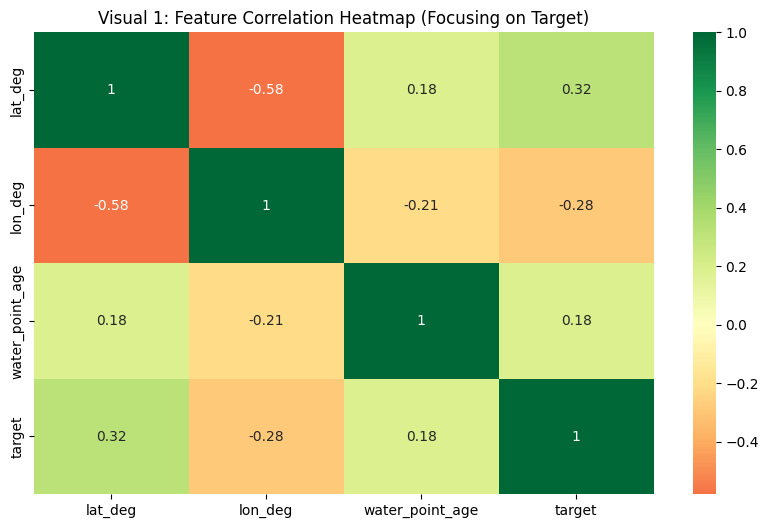

In [ ]:
# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[['lat_deg', 'lon_deg', 'water_point_age', 'target']].astype(float).corr(), 
            annot=True, cmap='RdYlGn', center=0)
plt.title('Visual 1: Feature Correlation Heatmap (Focusing on Target)')
plt.show()

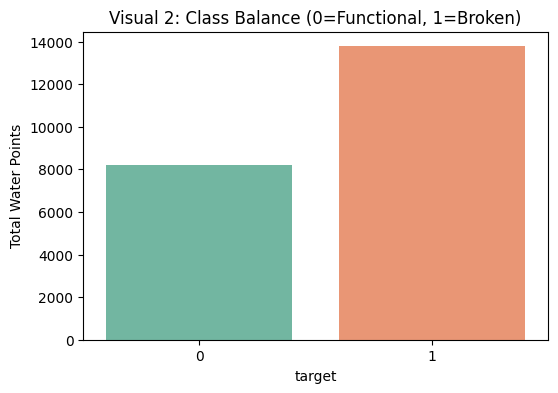

In [ ]:
# Class Balance (The Imbalance Problem)
plt.figure(figsize=(6, 4))
sns.countplot(x=y, hue=y, palette='Set2', legend=False)
plt.title('Visual 2: Class Balance (0=Functional, 1=Broken)')
plt.ylabel('Total Water Points')
plt.show()

# 5. Modeling
We are comparing Linear models, Bagging (Random Forest/Extra Trees), and Boosting (XGBoost/CatBoost). We use class_weight='balanced' or scale_pos_weight to handle the data imbalance.

### 5.1 Importing the necessary dependencies

In [ ]:
# 5.1 Importing the necessary dependencies

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

### 5.2 Train-Test Split (80/20)
We split our data using Stratified Sampling. This is critical because our target classes (Functional vs. Broken) are imbalanced. Stratification ensures that the training and testing sets have the same ratio of broken pumps, preventing the model from becoming biased toward the majority class.

In [ ]:
# We use 80% of data for training and 20% for unseen testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 17562
Testing set size: 4391


### Automated Preprocessing Pipeline

### 5.3 Feature Scaling and Encoding
We use a ColumnTransformer to handle different data types simultaneously:
Numerical Scaling: We apply StandardScaler to coordinates and age to ensure no single feature dominates due to its magnitude.
Categorical Encoding: We use OneHotEncoder with drop='first' to convert text categories into binary vectors while avoiding the "Dummy Variable Trap" (multicollinearity).

In [ ]:
# Defining the transformation logic for numerical and categorical features
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['lat_deg', 'lon_deg', 'water_point_age']),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), 
     ['water_source_clean', 'water_tech_clean', 'management_clean', 'pay_clean', 'is_urban'])
])

### 5.4 Model Selection and Imbalance Handling
We define five distinct algorithms ranging from linear baselines to advanced ensembles. To address the class imbalance identified in our EDA, we utilize parameters like class_weight='balanced' and scale_pos_weight. These parameters tell the models to penalize mistakes on "Broken" pumps more heavily than mistakes on "Functional" ones.

In [ ]:
# Dictionary of models for efficient iteration and comparison
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Extra Trees": ExtraTreesClassifier(class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=9, random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, auto_class_weights='Balanced', random_state=42)
}

print("Model definitions ready for training.")

Model definitions ready for training.


# 6. EVALUATION
### 6.1 Training and Evaluation Pipeline
In this phase, we iterate through our selected models. For each model, we create a Pipeline that first applies our preprocessing (scaling and encoding) and then fits the classifier.

Statistical Tuning: To meet our business goal of Recall > 0.8, we do not use the default 0.5 probability threshold. Instead, we extract the raw probabilities using .predict_proba() and apply a 0.2 Threshold. This makes the model more "sensitive" to potential failures

In [ ]:

from sklearn.metrics import roc_auc_score, classification_report, roc_curve, confusion_matrix, ConfusionMatrixDisplay

results = []
trained_pipelines = {}

# Iterate through the models dictionary
for name, model in models.items():
    # Creating and fitted the pipeline
    pipe = Pipeline([
        ('prep', preprocessor),
        ('clf', model)
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe # Store for later visualization
    
    # Getting predicted probabilities for the positive class (Broken)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    # Apply the custom 0.2 threshold to prioritize Recall
    y_pred = (y_proba >= 0.2).astype(int)
    
    # Calculating Metrics
    auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        "Model": name, 
        "ROC-AUC": auc, 
        "Recall": report['1']['recall'],   
        "Precision": report['1']['precision']
    })

# Convert results to a DataFrame for easy comparison
comparison_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print("Tournament Results (Sorted by AUC):")
print(comparison_df)

Tournament Results (Sorted by AUC):
                 Model   ROC-AUC    Recall  Precision
4             CatBoost  0.970152  0.937908   0.903779
1        Random Forest  0.968845  0.956064   0.853208
3              XGBoost  0.967193  0.981845   0.747581
2          Extra Trees  0.966177  0.948439   0.866622
0  Logistic Regression  0.952448  0.915759   0.883982


In [ ]:
# To see both classes side-by-side
print(classification_report(y_test, y_pred, target_names=['Functional', 'Non-Functional']))

                precision    recall  f1-score   support

    Functional       0.89      0.83      0.86      1637
Non-Functional       0.90      0.94      0.92      2754

      accuracy                           0.90      4391
     macro avg       0.90      0.88      0.89      4391
  weighted avg       0.90      0.90      0.90      4391



### Cross-Validation

In [ ]:
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
# Initializing the CatBoost model
cat_model = CatBoostClassifier(silent=True, random_state=42)

# 2. Build the Pipeline 
# This links your existing 'preprocessor' with the new 'cat_model'
catboost_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', cat_model)
])
# Fit the pipeline to your training data
catboost_pipe.fit(X_train, y_train)

print("catboost_pipe is now successfully defined!")

catboost_pipe is now successfully defined!


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
from sklearn.metrics import make_scorer, recall_score

# Definining the strategy (5 folds is standard for this dataset size)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Defining metrics for both classes (Broken = 1, Functional = 0)
scoring = {
    'auc': 'roc_auc',
    'recall_broken': make_scorer(recall_score, pos_label=1),
    'recall_functional': make_scorer(recall_score, pos_label=0)
}

# Running Cross-Validation
cv_results = cross_validate(catboost_pipe, X, y, cv=skf, scoring=scoring)

# Displaying the results
print(f"Mean ROC-AUC: {cv_results['test_auc'].mean():.4f} (+/- {cv_results['test_auc'].std():.4f})")
print(f"Mean Recall (Broken): {cv_results['test_recall_broken'].mean():.4f}")
print(f"Mean Recall (Functional): {cv_results['test_recall_functional'].mean():.4f}")

Mean ROC-AUC: 0.9687 (+/- 0.0026)
Mean Recall (Broken): 0.8922
Mean Recall (Functional): 0.9592


### 6.2 Performance Visualization: The Evidence
To validate our model selection, we visualize the results through three lenses:
Model Comparison: Assessing which architecture provides the best balance of AUC and Recall.
ROC-AUC Curve: Measuring the model’s ability to distinguish between "Functional" and "Broken" pumps at all thresholds.
Confusion Matrix: Quantifying the real-world impact of our custom 0.2 threshold—specifically how many communities we protect by identifying failing water points.

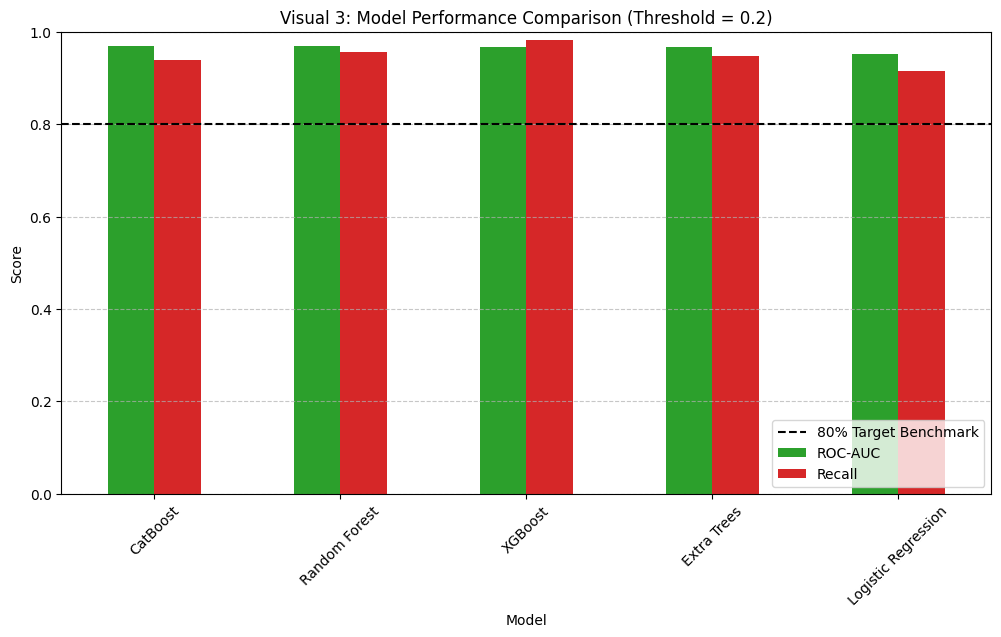

In [ ]:
# Model Tournament Comparison
comparison_df.set_index('Model')[['ROC-AUC', 'Recall']].plot(kind='bar', figsize=(12, 6), color=['#2ca02c', '#d62728'])
plt.axhline(0.8, color='black', linestyle='--', label='80% Target Benchmark')
plt.title('Visual 3: Model Performance Comparison (Threshold = 0.2)')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

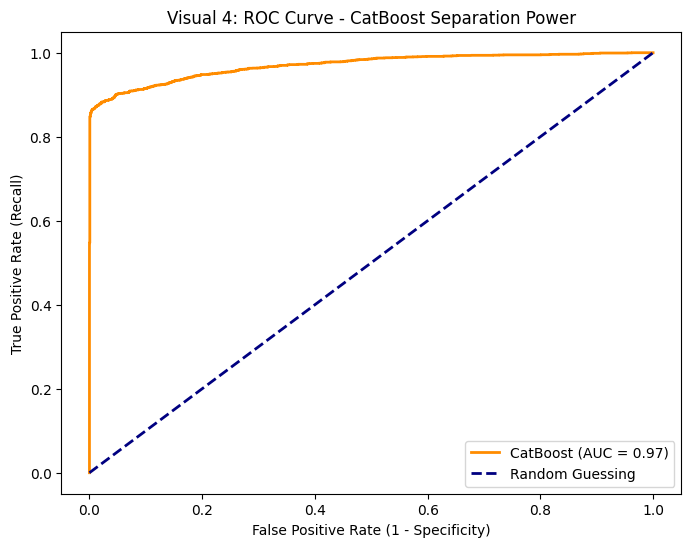

In [ ]:
# ROC Curve for the Top Model
# We select the model that performed best in the tournament
best_model_name = comparison_df.iloc[0]['Model']
best_pipe = trained_pipelines[best_model_name]
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'{best_model_name} (AUC = {comparison_df.iloc[0]["ROC-AUC"]:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title(f'Visual 4: ROC Curve - {best_model_name} Separation Power')
plt.legend(loc="lower right")
plt.show()

<Figure size 800x600 with 0 Axes>

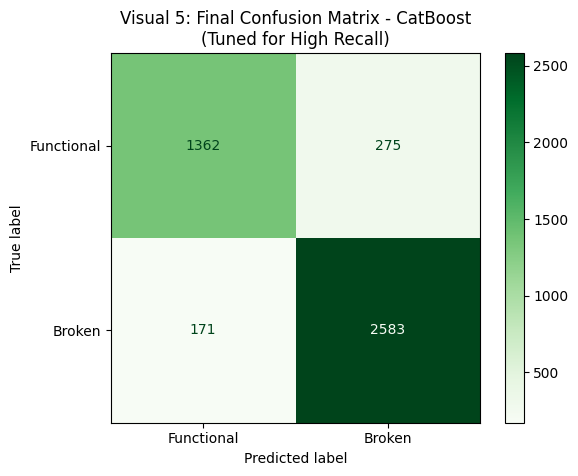

In [ ]:
# Confusion Matrix (Business Impact)
# Applying our 0.2 threshold to the best model
y_pred_final = (y_proba_best >= 0.2).astype(int)
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Functional', 'Broken'])
disp.plot(cmap='Greens', values_format='d')
plt.title(f'Visual 5: Final Confusion Matrix - {best_model_name}\n(Tuned for High Recall)')
plt.show()